Импорт модулей:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

import warnings
warnings.filterwarnings('ignore')


import torch
import torch.nn.functional as F
import torchvision
import os
from torch import nn
from tqdm import tqdm
import numpy as np

Изменил batch_size с 64 до 128, чтобы немного уменьшить время обучения и скорость переобучения

In [2]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=128, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=128, shuffle=True)

def train(model, optimizer, n_epochs=5):
    val_loss_epochs = []
    val_accuracy_epochs = []

    for epoch in range(n_epochs):
        # обучение
        for x_train, y_train in tqdm(train_dataloader):
            y_pred = model(x_train)
            loss = F.nll_loss(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # валидация
        if epoch % 2 == 0:
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    y_pred = model(x_val)
                    loss = F.nll_loss(y_pred, y_val)
                    val_loss.append(loss.numpy())
                    val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())

            print(f'Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}')

        val_loss_epochs.append(np.mean(val_loss))
        val_accuracy_epochs.append(np.mean(val_accuracy))

    return val_loss_epochs, val_accuracy_epochs

Тестирую на моделе разные значения параметров для out_cannels и kernel_size

100%|██████████| 79/79 [00:01<00:00, 72.12it/s]


Epoch: 0, loss: 0.4199463427066803, accuracy: 0.8639


100%|██████████| 79/79 [00:01<00:00, 74.46it/s]


Epoch: 2, loss: 0.32544639706611633, accuracy: 0.8978


100%|██████████| 79/79 [00:01<00:00, 74.72it/s]


...

Epoch: 0, loss: 0.096262127161026, accuracy: 0.9692


100%|██████████| 79/79 [00:01<00:00, 67.43it/s]


Epoch: 2, loss: 0.07085898518562317, accuracy: 0.979


100%|██████████| 79/79 [00:01<00:00, 67.59it/s]


Epoch: 4, loss: 0.05623584985733032, accuracy: 0.9816


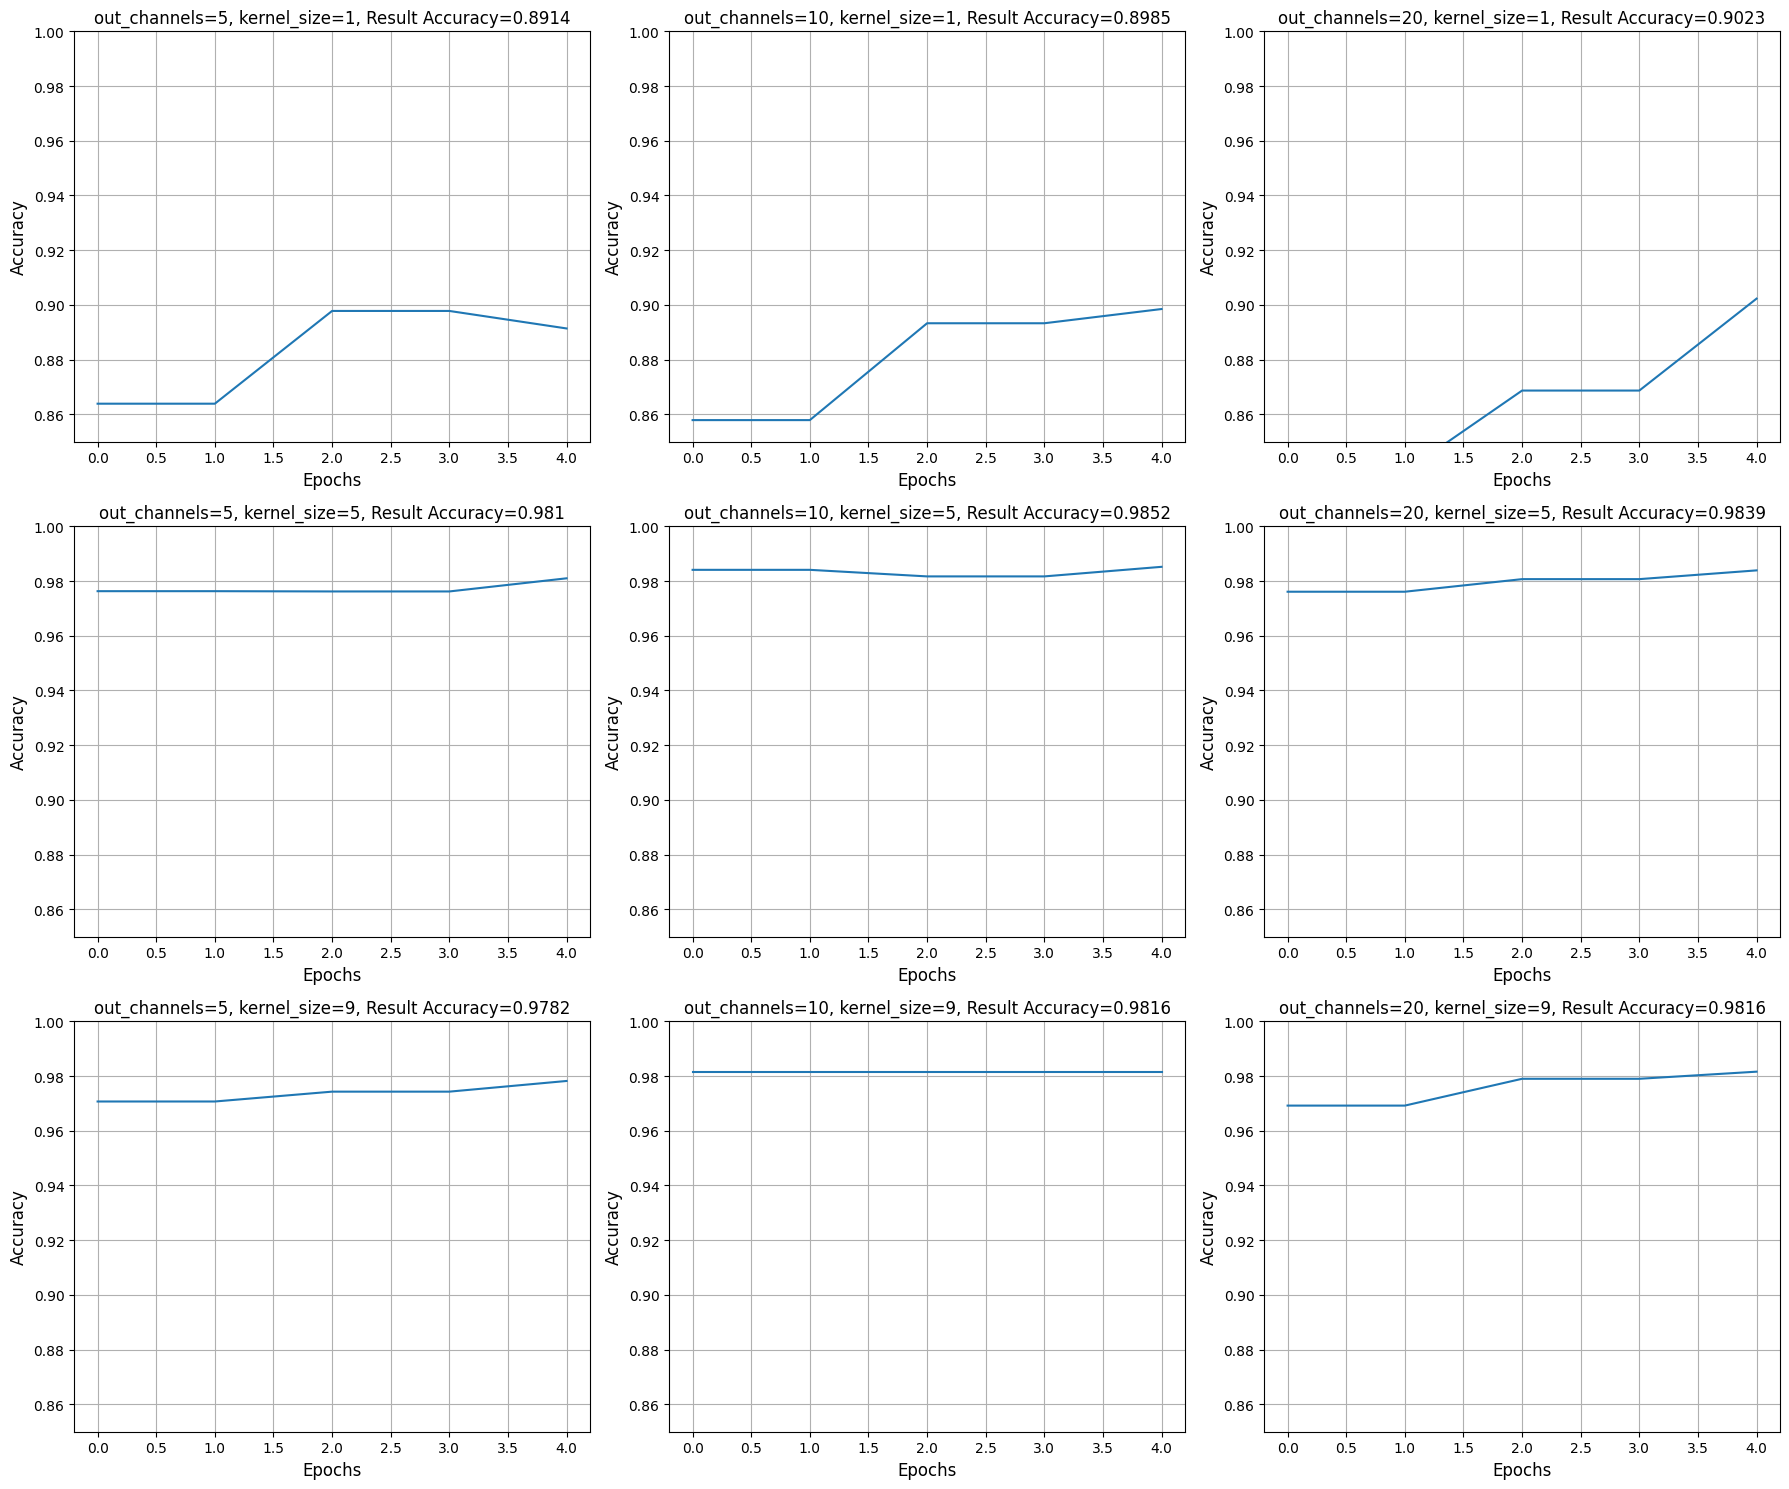

In [5]:
out_cannels_arr = [5, 10, 20]
kernel_size_arr = [1, 5, 9]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))  

for i in range(9):
    out_cannels = out_cannels_arr[i % 3]
    kernel_size = kernel_size_arr[i // 3]

    lin_layer = (((28 - kernel_size + 1) // 4) ** 2) * out_cannels

    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=out_cannels, kernel_size=kernel_size),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=4),  
        nn.Flatten(),
        nn.Linear(lin_layer, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
        nn.LogSoftmax(dim=1)
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    val, val_ac = train(model, optimizer)

    ax = axes[i // 3, i % 3]
    ax.plot(val_ac)
    ax.set_title(f"out_channels={out_cannels}, kernel_size={kernel_size}, Result Accuracy={val_ac[-1]}")
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_ylim(0.85, 1)  
    ax.grid()

plt.tight_layout()
plt.show()

Наиболее лучший результат показала изначальная модель. Второй по величине accuracy оназалась модель с параметрами out_channels=20, kernel_size=5. По графику видно, что она ведёт себя более стабильно, чем первая. Также по графику видно, что за 4 эпохи модель так и не начала переобучаться.
У неё я уменьшаю learning_rate, ставлю weight_decay=1e-4 чтобы уменьшить переобучение и увеличиваю количество эпох.

100%|██████████| 79/79 [00:01<00:00, 63.78it/s]


Epoch: 0, loss: 0.09561102837324142, accuracy: 0.9726


100%|██████████| 79/79 [00:01<00:00, 64.51it/s]


Epoch: 2, loss: 0.05444081872701645, accuracy: 0.9803


100%|██████████| 79/79 [00:01<00:00, 63.08it/s]


...

Epoch: 20, loss: 0.029632894322276115, accuracy: 0.9904


100%|██████████| 79/79 [00:01<00:00, 56.12it/s]


Epoch: 22, loss: 0.027681482955813408, accuracy: 0.9908


100%|██████████| 79/79 [00:01<00:00, 56.62it/s]

Epoch: 24, loss: 0.03309483826160431, accuracy: 0.9891


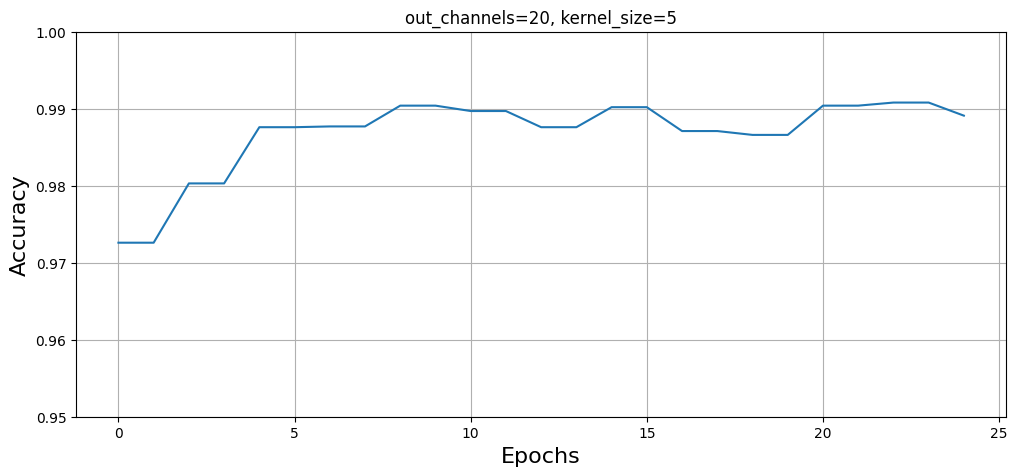

In [24]:
seed_everything(42)
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5),  # grayscale
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),   # сократим изображение в 4 раза по каждой из сторон
    nn.Flatten(),
    nn.Linear(6*6*20, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    nn.LogSoftmax(dim=1)
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
val, val_ac = train(model, optimizer, n_epochs=25)

plt.figure(figsize=(12, 5))
plt.plot(val_ac)
plt.title('out_channels=20, kernel_size=5')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.ylim(0.95, 1) 
plt.grid()
plt.show()


По графику видно, что accuracy прекращает свой рост примерно на 8 эпохе.

100%|██████████| 79/79 [00:01<00:00, 64.05it/s]


Epoch: 0, loss: 0.09561102837324142, accuracy: 0.9726


100%|██████████| 79/79 [00:01<00:00, 61.97it/s]


Epoch: 2, loss: 0.05444081872701645, accuracy: 0.9803


100%|██████████| 79/79 [00:01<00:00, 62.97it/s]


Epoch: 4, loss: 0.037446875125169754, accuracy: 0.9876


100%|██████████| 79/79 [00:01<00:00, 60.58it/s]


Epoch: 6, loss: 0.036155104637145996, accuracy: 0.9877


100%|██████████| 79/79 [00:01<00:00, 60.91it/s]

Epoch: 8, loss: 0.027333833277225494, accuracy: 0.9904


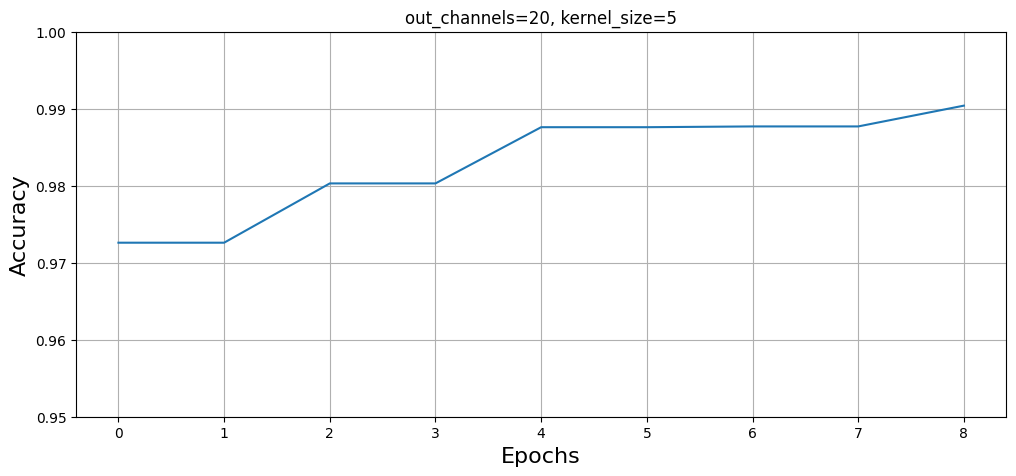

Final Accuracy = 0.9904


In [25]:
seed_everything(42)
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5),  # grayscale
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),   # сократим изображение в 4 раза по каждой из сторон
    nn.Flatten(),
    nn.Linear(6*6*20, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    nn.LogSoftmax(dim=1)
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
val, val_ac = train(model, optimizer, n_epochs=9)

plt.figure(figsize=(12, 5))
plt.plot(val_ac)
plt.title('out_channels=20, kernel_size=5')
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.ylim(0.95, 1) 
plt.grid()
plt.show()

print('Final Accuracy =', val_ac[-1])